In [3]:
# Import general dependencies
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

eps = 1e-4

# ==================================
# ======== Gaussian filter =========
# ==================================

# This code is based on https://github.com/Attila94/CIConv/blob/main/method/ciconv2d.py

def gaussian_basis_filters(scale, gpu, k=3):
    std = torch.pow(2,scale)

    # Define the basis vector for the current scale
    filtersize = torch.ceil(k*std+0.5)
    x = torch.arange(start=-filtersize.item(), end=filtersize.item()+1)
    if gpu is not None: x = x.to(gpu); std = std.to(gpu)
    x = torch.meshgrid([x,x])

    # Calculate Gaussian filter base
    # Only exponent part of Gaussian function since it is normalized anyway
    g = torch.exp(-(x[0]/std)**2/2)*torch.exp(-(x[1]/std)**2/2)
    g = g / torch.sum(g)  # Normalize

    # Gaussian derivative dg/dx filter base
    dgdx = -x[0]/(std**3*2*math.pi)*torch.exp(-(x[0]/std)**2/2)*torch.exp(-(x[1]/std)**2/2)
    dgdx = dgdx / torch.sum(torch.abs(dgdx))  # Normalize

    # Gaussian derivative dg/dy filter base
    dgdy = -x[1]/(std**3*2*math.pi)*torch.exp(-(x[1]/std)**2/2)*torch.exp(-(x[0]/std)**2/2)
    dgdy = dgdy / torch.sum(torch.abs(dgdy))  # Normalize

    # Stack and expand dim
    basis_filter = torch.stack([g,dgdx,dgdy], dim=0)[:,None,:,:]

    return basis_filter

def convolve_gaussian_filters(batch, scale):
    E, El, Ell = torch.split(batch, 1, dim=1)
    E_out, El_out, Ell_out = [], [], []

    for s in range(len(scale)):
        # Convolve with Gaussian filters
        w = gaussian_basis_filters(scale=scale[s:s+1], gpu=batch.device).to(dtype=batch.dtype)  # KCHW

        # the padding here works as "same" for odd kernel sizes
        E_out.append(F.conv2d(input=E[s:s+1,:,:,:], weight=w, padding=int(w.shape[2]/2)))
        El_out.append(F.conv2d(input=El[s:s+1,:,:,:], weight=w, padding=int(w.shape[2]/2)))
        Ell_out.append(F.conv2d(input=Ell[s:s+1,:,:,:], weight=w, padding=int(w.shape[2]/2)))

    return torch.cat(E_out), torch.cat(El_out), torch.cat(Ell_out)

# =================================
# == Color invariant definitions ==
# =================================

def hat_H(E,Ex,Ey,El,Elx,Ely,Ell,Ellx,Elly):
    return torch.atan(El/(Ell+eps))

def hat_S(E,Ex,Ey,El,Elx,Ely,Ell,Ellx,Elly):
    return (El**2 + Ell**2) / (E**2 +eps) 

def hat_Ww(E,Ex,Ey,El,Elx,Ely,Ell,Ellx,Elly):
    Wx = Ex / (E+eps)
    Wy = Ey / (E+eps)
    return Wx**2 + Wy**2

def hat_Wlw2(E,Ex,Ey,El,Elx,Ely,Ell,Ellx,Elly):
    Wlx = Elx / (E+eps)
    Wly = Ely / (E+eps)
    return Wlx**2 + Wly**2

def hat_Wllw2(E,Ex,Ey,El,Elx,Ely,Ell,Ellx,Elly):
    Wllx = Ellx / (E+eps)
    Wlly = Elly / (E+eps)
    return Wllx**2 + Wlly**2

# =================================
# == Color invariant convolution ==
# =================================

class PriorConv2d(nn.Module):
    def __init__(self, invariant, k=3, scale=0.0):

        super(PriorConv2d, self).__init__()
        self.use_cuda = torch.cuda.is_available()

        # Constants
        self.gcm = torch.nn.Parameter(torch.tensor([[0.06,0.63,0.27],[0.3,0.04,-0.35],[0.34,-0.6,0.17]]))
        self.k = k
            
        self.conv = torch.nn.Sequential(
            torch.nn.Conv2d(3, 16, 3, padding=1),
            nn.SiLU(),
            torch.nn.Conv2d(16, 16, 3, padding=1),
            nn.SiLU(),
            torch.nn.Conv2d(16, 1, 3, padding=1)
        )

    def forward(self, batch):
        # Make sure scale does not explode: clamp to max abs value of 2.5
        # self.scale.data = torch.clamp(self.scale.data, min=-2.5, max=2.5)

        with torch.no_grad():
            max_RGB = torch.argmax(batch, dim=1)
            min_RGB = torch.argmin(batch, dim=1)

            batch_ = torch.flip(batch, dims=(1,))

            max_RGB_ = 2 - torch.argmax(batch_, dim=1)
            min_RGB_ = 2 - torch.argmin(batch_, dim=1)

            RGB_order = torch.zeros(batch.shape, device=batch.device, dtype=batch.dtype)
            RGB_order = RGB_order.scatter_(1, max_RGB.unsqueeze(1), 0.5, reduce='add')
            RGB_order = RGB_order.scatter_(1, max_RGB_.unsqueeze(1), 0.5, reduce='add')
            RGB_order = RGB_order.scatter_(1, min_RGB.unsqueeze(1), -0.5, reduce='add')
            RGB_order = RGB_order.scatter_(1, min_RGB_.unsqueeze(1), -0.5, reduce='add')

        scale = torch.mean(self.conv(batch), dim=(1,2,3))
        scale = torch.clamp(scale, min=-2.5, max=2.5) 

        # Measure E, El, Ell by Gaussian color model
        in_shape = batch.shape  # bchw
        batch = batch.view((in_shape[:2]+(-1,)))  # flatten image
        batch = torch.matmul(self.gcm.to(batch.device, dtype=batch.dtype), batch)  # estimate E,El,Ell
        batch = batch.view((in_shape[0],)+(3,)+in_shape[2:])  # reshape to original image size

        E_out, El_out, Ell_out = convolve_gaussian_filters(batch.float(), scale.float())

        if False:
            print("Ws")
            E, Ex, Ey = torch.split(E_out,1,dim=1)
            El, Elx, Ely = torch.split(El_out,1,dim=1)
            Ell, Ellx, Elly = torch.split(Ell_out,1,dim=1)

            H = hat_H(E,Ex,Ey,El,None,None,Ell,None,None)
            S = torch.log(hat_S(E,Ex,Ey,El,None,None,Ell,None,None)+eps)
            Ww = torch.atan(hat_Ww(E,Ex,Ey,El,None,None,Ell,None,None) + \
                            hat_Wlw2(E,Ex,Ey,El,Elx,Ely,Ell,Ellx,Elly) + \
                            hat_Wllw2(E,Ex,Ey,El,Elx,Ely,Ell,Ellx,Elly))
        else:
            # print("W1")
            E, Ex, Ey = torch.split(E_out,1,dim=1)
            El = torch.split(El_out,1,dim=1)[0]
            Ell = torch.split(Ell_out,1,dim=1)[0]

            H = hat_H(E,Ex,Ey,El,None,None,Ell,None,None)
            S = torch.log(hat_S(E,Ex,Ey,El,None,None,Ell,None,None)+eps)
            Ww = torch.atan(hat_Ww(E,Ex,Ey,El,None,None,Ell,None,None))
            
            print(f'H:{H.shape},S:{S.shape},RGB_order:{RGB_order.shape},Ww:{Ww.shape}')
            
        features = torch.cat([H, S, RGB_order, Ww], dim=1)
        return features.to(dtype=batch.dtype)

In [4]:
from PIL import Image
import numpy as np
from torchvision import transforms
import matplotlib.pyplot as plt

C:\Users\25232\anaconda3\envs\pytorch\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: 'Could not find module 'C:\Users\25232\anaconda3\envs\pytorch\Lib\site-packages\torchvision\image.pyd' (or one of its dependencies). Try using the full path with constructor syntax.'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [11]:
def grab(img_path):
    img = np.array(Image.open(img_path))
    img_tensor = torch.tensor(img)/255
    return img_tensor

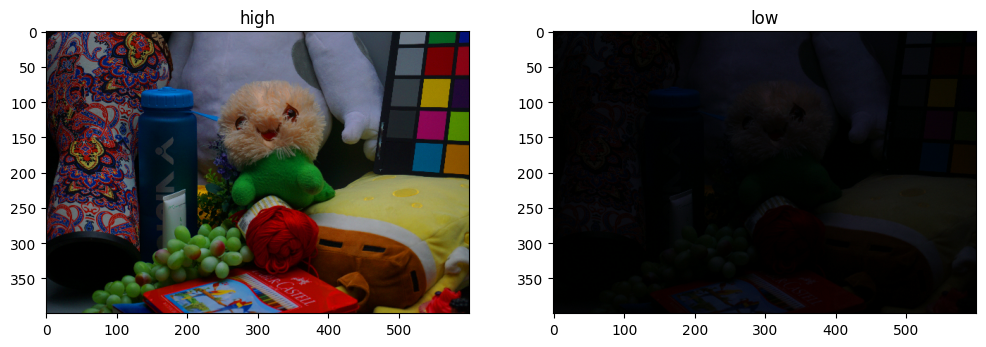

In [66]:
num = 493
high_path = f'eval15/high/{num}.png'
low_path = f'eval15/low/{num}.png'

image_high = grab(high_path)
image_low = grab(low_path)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(image_high)
plt.title('high')

plt.subplot(1,2,2)
plt.imshow(image_low)
plt.title('low')
plt.show()

In [67]:
image_high.shape

torch.Size([400, 600, 3])

In [68]:
image_high_ = image_high.permute(2,0,1).unsqueeze(0)
image_low_ = image_low.permute(2,0,1).unsqueeze(0)

In [69]:
image_high_.shape

torch.Size([1, 3, 400, 600])

In [70]:
model = PriorConv2d('W', k=3, scale=0.0)
with torch.no_grad():
    out1 = model(image_high_)
    out2 = model(image_low_)

H:torch.Size([1, 1, 400, 600]),S:torch.Size([1, 1, 400, 600]),RGB_order:torch.Size([1, 3, 400, 600]),Ww:torch.Size([1, 1, 400, 600])
H:torch.Size([1, 1, 400, 600]),S:torch.Size([1, 1, 400, 600]),RGB_order:torch.Size([1, 3, 400, 600]),Ww:torch.Size([1, 1, 400, 600])


In [71]:
out1.dtype

torch.float32

In [72]:
out1[0][2:5].unsqueeze(2).dtype

torch.float32

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


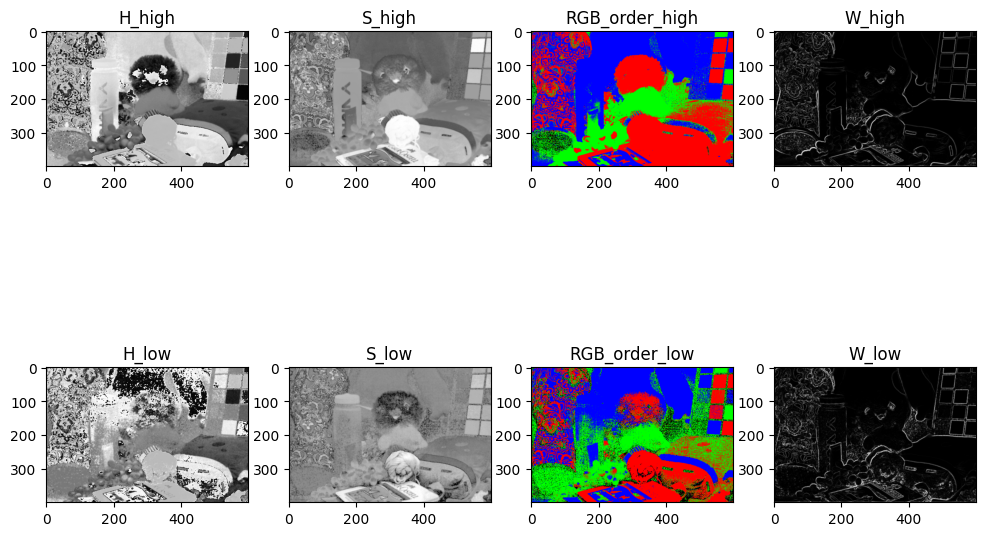

In [73]:
plt.figure(figsize=(12,8))
plt.subplot(2,4,1)
plt.imshow(out1[0][0].unsqueeze(2),cmap='gray')
plt.title('H_high')

plt.subplot(2,4,2)
plt.imshow(out1[0][1].unsqueeze(2),cmap='gray')
plt.title("S_high")


plt.subplot(2,4,3)
plt.imshow(out1[0][2:5].permute(1,2,0))
plt.title("RGB_order_high")

plt.subplot(2,4,4)
plt.imshow(out1[0][-1].unsqueeze(2),cmap='gray')
plt.title("W_high")


plt.subplot(2,4,5)
plt.imshow(out2[0][0].unsqueeze(2),cmap='gray')
plt.title('H_low')

plt.subplot(2,4,6)
plt.imshow(out2[0][1].unsqueeze(2),cmap='gray')
plt.title("S_low")


plt.subplot(2,4,7)
plt.imshow(out2[0][2:5].permute(1,2,0))
plt.title("RGB_order_low")

plt.subplot(2,4,8)
plt.imshow(out2[0][-1].unsqueeze(2),cmap='gray')
plt.title("W_low")

plt.savefig(f'temp/{num}.png')
plt.show()
